# Defining global variables

In [1]:
REPO_NAME = 'Textual_Analysis_in_Finance'
BASE_DIR = f'/kaggle/working/{REPO_NAME}'
WEEK = 1

# Clone the lecture's git repo

In [2]:
!git clone https://github.com/minhtriphan/{REPO_NAME}.git
%cd {REPO_NAME}

Cloning into 'Textual_Analysis_in_Finance'...
remote: Enumerating objects: 68, done.
remote: Counting objects: 100% (68/68), done.
remote: Compressing objects: 100% (57/57), done.
remote: Total 68 (delta 12), reused 64 (delta 8), pack-reused 0 (from 0)
Receiving objects: 100% (68/68), 425.85 KiB | 10.65 MiB/s, done.
Resolving deltas: 100% (12/12), done.
/kaggle/working/Textual_Analysis_in_Finance


# Install necessary packages

In [3]:
!pip install contractions
!pip install wordcloud

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 6.9 MB/s eta 0:00:00


# Normalizing texts

#### Examples

I have written some functions to normalize texts, the functions are in the `Utils.py` file. They include code to:

* Read a .txt file
* Convert a text into lowercase
* Remove special characters
* Fix contractions (e.g., I'll -> I will)
* Remove stopwords
* Lemmatize the text

To use them, we can simply import them as follows

`from Week_1.Code.Utils import readfile, lowercase, special_character_removal, fix_contraction, stopword_removal, lemmatization`

In [4]:
from Week_1.Code.Utils import readfile, lowercase, special_character_removal, fix_contraction, stopword_removal, lemmatization
import os # Package for manipulating the operating system
from glob import glob # Package to get the file names that match a fixed pattern

all_files = glob(os.path.join(BASE_DIR, 'Data', 'Transcripts', '*.txt'))
sample_file = all_files[0]
print(f'There are {len(all_files)} files')
print('A sample file name is:', sample_file)

########## Questions ##########
'''
1. Can you explain the information in the file's name? Especially what does this (transcript_NVDA_2023_Q4_20230222.txt) mean?
'''

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


There are 24 files
A sample file name is: /kaggle/working/Textual_Analysis_in_Finance/Data/Transcripts/transcript_NVDA_2020_Q1_20190516.txt


"\n1. Can you explain the information in the file's name? Especially what does this (transcript_NVDA_2023_Q4_20230222.txt) mean?\n"

* To learn about a function, use the `help()` method

In [5]:
'''
Answer: in NVDA_2023_Q4_20230222

- NVDA: the ticker
- 2023: fiscal year
- Q4: fiscal quarter
- 20230222: the date of the call, 22nd Feb 2023. You will see some cases where a call takes place in 2024 but the fiscal year is 2025
'''

'\nAnswer: in NVDA_2023_Q4_20230222\n\n- NVDA: the ticker\n- 2023: fiscal year\n- Q4: fiscal quarter\n- 20230222: the date of the call, 22nd Feb 2023. You will see some cases where a call takes place in 2024 but the fiscal year is 2025\n'

In [6]:
help(readfile)

Help on function readfile in module Week_1.Code.Utils:

readfile(f: str) -> str
    This function reads the content of a .txt file.
    Args:
      - f (str): the file name with full directory.
    Output:
      - File content (str)



* Let's try it

In [7]:
readfile(sample_file)[:500]

"Operator: Good afternoon. My name is Kristina, and I'll be your conference operator today. Welcome to NVIDIA's financial results conference call. All lines have been placed on mute. [Operator Instructions] I'll now turn the call over to Simona Jankowski from Investor Relations to begin your conference.\nSimona Jankowski: Thank you. Good afternoon, everyone. And welcome to NVIDIA's conference call for the first quarter of fiscal 2020. With me on the call today from NVIDIA are Jen-Hsun Huang, Presi"

#### The normalization pipeline

In [8]:
content = readfile(sample_file)
print('*' * 30)
print('Raw content:', content[:100])
text = lowercase(content)
print('*' * 30)
print('Lowercase text:', text[:100])
text = fix_contraction(text)
print('*' * 30)
print('Text with corrected contractions:', text[:100])
text = special_character_removal(text, keep = '.', remove_number = True)
print('*' * 30)
print('Text after removing special characters:', text[:100])
text = stopword_removal(text, remove_single_letters = True)
print('*' * 30)
print('Text after removing stopwords:', text[:100])
text = lemmatization(text)
print('*' * 30)
print('Clean text:', text[:100])

******************************
Raw content: Operator: Good afternoon. My name is Kristina, and I'll be your conference operator today. Welcome t
******************************
Lowercase text: operator: good afternoon. my name is kristina, and i'll be your conference operator today. welcome t
******************************
Text with corrected contractions: operator: good afternoon. my name is kristina, and i will be your conference operator today. welcome
******************************
Text after removing special characters: operator good afternoon. my name is kristina and i will be your conference operator today. welcome t
******************************
Text after removing stopwords: operator good afternoon. name kristina conference operator today. welcome nvidia financial results c
******************************
Clean text: operator good afternoon . name kristina conference operator today . welcome nvidia financial result 


#### Your turn: Can you write your own functions?

* Before that, you need some packages below

In [9]:
from typing import Optional, List
# To remove special characters
import re
# To fix contractions
import contractions    # Don't forget to install it via `pip install contractions`
# To remove stopwords
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')
# To lemmatize
import spacy
LEMMATIZER = spacy.load('en_core_web_sm')

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [10]:
def my_readfile(f: str) -> str:
    '''
    <Write function description>
    '''
    # Write function body
    
    return ...

def my_lowercase(f: str) -> str:
    '''
    <Write function description>
    '''
    # Write function body
    
    return ...

def my_fix_contraction(f: str) -> str:
    '''
    <Write function description>
    '''
    # Write function body
    
    return ...

def my_special_character_removal(txt: str, keep: Optional[str] = None, remove_number: bool = False) -> str:
    '''
    <Write function description>
    '''
    # Write function body
    
    return ...

def my_stopword_removal(txt: str, stopword_list: List = stopwords.words('english'), remove_single_letters: bool = False) -> str:
    '''
    <Write function description>
    '''
    # Write function body
    
    return ...

def my_lemmatization(txt: str) -> str:
    '''
    <Write function description>
    '''
    # Write function body
    
    return ...

#### Advanced

* You can wrap everything in a Python object. REMEMBER: The object should be self-contained

In [11]:
from Week_1.Code.Utils import readfile, lowercase, special_character_removal, fix_contraction, stopword_removal, lemmatization
from typing import Optional, List
import re
import contractions
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')
import spacy
LEMMATIZER = spacy.load('en_core_web_sm')

class TextNormalizer(object):
    '''
    This object normalizes texts.
    Example run:
        text_normalizer = TextNormalizer()
        clean_text = text_normalizer(f)    # f is a file's name
    Args (in __call__):
        - f (str): the file name with full directory.
        - special_characters_to_keep (str): A string storing punctuations to keep. For example: ',.()'. Default: None, which means exclude all punctuations.
        - remove_number (bool): Whether remove numbers or not. Default: False.
        - remove_single_letters (bool): Whether to remove single letters, such as a, b, c, etc., or not. Default: False.
    '''
    def __init__(self):
        pass

    def __call__(
        self, 
        f: str, 
        special_characters_to_keep: Optional[str] = None, 
        remove_number: bool = False, 
        remove_single_letters: bool = False
    ) -> str:        
        content = readfile(f)
        text = lowercase(content)
        text = fix_contraction(text)
        text = special_character_removal(text, keep = special_characters_to_keep, remove_number = remove_number)
        text = stopword_removal(text, remove_single_letters = remove_single_letters)
        text = lemmatization(text)
        return text

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


* Try

In [12]:
text_normalizer = TextNormalizer()
clean_text = text_normalizer(sample_file)
print(clean_text[:500])

operator good afternoon name kristina conference operator today welcome nvidia financial result conference call line place mute operator instruction turn call simona jankowski investor relation begin conference simona jankowski thank good afternoon everyone welcome nvidia conference call first quarter fiscal 2020 call today nvidia jen hsun huang president chief executive officer colette kress executive vice president chief financial officer would like remind call webcast live nvidia investor rel


#### Normalize all files

In [13]:
from tqdm.auto import tqdm    # Package for checking progress

corpus = []

for f in tqdm(all_files):
    # Normalizing
    content = readfile(f)
    text = lowercase(content)
    text = fix_contraction(text)
    text = special_character_removal(text, keep = '.', remove_number = True)
    text = stopword_removal(text, remove_single_letters = True)
    text = lemmatization(text)
    # Storing the clean texts
    corpus.append(text)

for text in corpus:
    print(text[:500])

  0%|          | 0/24 [00:00<?, ?it/s]

operator good afternoon . name kristina conference operator today . welcome nvidia financial result conference call . line place mute . operator instruction turn call simona jankowski investor relation begin conference . simona jankowski thank you . good afternoon everyone . welcome nvidia conference call first quarter fiscal . call today nvidia jen hsun huang president chief executive officer colette kress executive vice president chief financial officer . would like remind call webcast live nv
operator good afternoon . name david conference operator today . time would like welcome everyone nvidia financial result conference call . operator instruction thank you . simona jankowski may begin conference . simona jankowski thank you . good afternoon everyone welcome nvidia conference call second quarter fiscal . call today nvidia jensen huang president chief executive officer colette kress executive vice president chief financial officer . would like remind call webcast live nvidia inves

# Text feature extraction

#### Hashing

* Object: `sklearn.feature_extraction.text.HashingVectorizer`
* Documentation: https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.HashingVectorizer.html
* Most important argument: `n_features`

In [14]:
from sklearn.feature_extraction.text import HashingVectorizer

# Define the Hasing object
vectorizer = HashingVectorizer(n_features = 8)

# Convert texts into matrix
X_hashing = vectorizer.fit_transform(corpus)
X_hashing.toarray()

array([[ 0.09560463, -0.07767876,  0.26888803, -0.70508416,  0.51985019,
        -0.13743166,  0.23901158, -0.26291274],
       [-0.00532979, -0.14923414,  0.13324477, -0.38374494,  0.83144736,
         0.        ,  0.17055331,  0.30379808],
       [-0.08860629, -0.1605989 , -0.04984104, -0.58701668,  0.60916826,
        -0.08860629,  0.36550095,  0.3267357 ],
       [ 0.19706143, -0.0371814 ,  0.0557721 , -0.43130426,  0.73619175,
         0.01487256,  0.43874054,  0.18962515],
       [ 0.18269377, -0.08020702, -0.19160567, -0.59709673,  0.43668268,
        -0.03119162,  0.60155267, -0.11585459],
       [ 0.17866409, -0.26393559, -0.09745314, -0.4019942 ,  0.38169147,
        -0.07308986,  0.62532432, -0.43041804],
       [ 0.45285964,  0.08957663,  0.00995296, -0.47276555,  0.55736571,
        -0.07962367,  0.47774203,  0.13436495],
       [ 0.0894491 , -0.53669461,  0.05552013, -0.38864092,  0.53361015,
        -0.08636465,  0.47500557, -0.1788982 ],
       [ 0.01112571, -0.22807715

* You can just input the list of file names instead of clean texts into the `vectorizer`. In this case, we need to set `input = 'filename'` and define the argument `preprocessor` by your text processing function/object.
* NOTICE: `preprocessor` takes a FUNCTION as input. That function must take a text (content, str), NOT A FILE NAME, and output a clean text.

In [15]:
def text_normalizer(text):
    text = lowercase(text)
    text = fix_contraction(text)
    text = special_character_removal(text, keep = '.', remove_number = True)
    text = stopword_removal(text, remove_single_letters = True)
    text = lemmatization(text)
    return text
    
vectorizer = HashingVectorizer(input = 'filename', n_features = 8, preprocessor = text_normalizer)
X_hashing = vectorizer.fit_transform(all_files)
X_hashing.toarray()

array([[ 0.09560463, -0.07767876,  0.26888803, -0.70508416,  0.51985019,
        -0.13743166,  0.23901158, -0.26291274],
       [-0.00532979, -0.14923414,  0.13324477, -0.38374494,  0.83144736,
         0.        ,  0.17055331,  0.30379808],
       [-0.08860629, -0.1605989 , -0.04984104, -0.58701668,  0.60916826,
        -0.08860629,  0.36550095,  0.3267357 ],
       [ 0.19706143, -0.0371814 ,  0.0557721 , -0.43130426,  0.73619175,
         0.01487256,  0.43874054,  0.18962515],
       [ 0.18269377, -0.08020702, -0.19160567, -0.59709673,  0.43668268,
        -0.03119162,  0.60155267, -0.11585459],
       [ 0.17866409, -0.26393559, -0.09745314, -0.4019942 ,  0.38169147,
        -0.07308986,  0.62532432, -0.43041804],
       [ 0.45285964,  0.08957663,  0.00995296, -0.47276555,  0.55736571,
        -0.07962367,  0.47774203,  0.13436495],
       [ 0.0894491 , -0.53669461,  0.05552013, -0.38864092,  0.53361015,
        -0.08636465,  0.47500557, -0.1788982 ],
       [ 0.01112571, -0.22807715

#### Bag-of-Words
* Object: `sklearn.feature_extraction.text.CountVectorizer`
* Documentation: https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.CountVectorizer.html
* Important arguments:

    - `preprocessor`: as before
    - `max_df` (or **max**imum **d**ocument **f**requency): ignore terms that have a document frequency strictly **higher** than the given threshold
    - `min_df` (or **min**imum **d**ocument **f**requency): ignore terms that have a document frequency strictly **lower** than the given threshold
    - `vocabulary`: in case you want to focus on a specific set of words
    - `max_features`: choose only a given amount of words with the highest frequency
    - `ngram_range`: The lower and upper boundary of the range of n-values for different word n-grams to be extracted
* To check the vocabulary: use the `.get_feature_names_out()` method

In [16]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer()
X_bow = vectorizer.fit_transform(corpus)
X_bow

########## Questions ##########
'''
2. Can you explain what the dimensions of X_bow mean?
'''

'\n2. Can you explain what the dimensions of X_bow mean?\n'

In [17]:
'''
Answer:
- The number of rows = the number of documents in the corpus
- The number of columns = the number of words in the vocabulary
'''
print('The number of rows = the number of documents in the corpus?', X_bow.shape[0] == len(corpus))
print('The number of rows = the number of documents in the corpus?', X_bow.shape[1] == len(vectorizer.get_feature_names_out()))

The number of rows = the number of documents in the corpus? True
The number of rows = the number of documents in the corpus? True


In [18]:
########## Questions ##########
'''
3. Can you compute the cosine similarity of NVIDIA's earnings call?
'''

"\n3. Can you compute the cosine similarity of NVIDIA's earnings call?\n"

The cosine similarity between two vectors $x = (x_1, x_2, ..., x_d)$ and $y = (y_1, y_2, ..., y_d)$ are computed as

$cosine\_similarity(x, y) = \frac{(x_1y_1 + ... + x_dy_d)}{\sqrt{(x^2_1 + ... + x^2_d)(y^2_1 + ... + y^2_d)}}$

In [19]:
'''Answer'''
import numpy as np

normalized_X_bow = X_bow / np.sqrt(X_bow.power(2).sum(axis = 1))
cosine_similarity = (normalized_X_bow @ normalized_X_bow.T).toarray()

## Can you try the same with TF-IDF?

#### Tf-idf
* Object: `sklearn.feature_extraction.text.TfidfVectorizer`
* Documentation: https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html
* Important arguments:

In [20]:
from sklearn.feature_extraction.text import TfidfVectorizer

'''YOUR CODE HERE'''

'YOUR CODE HERE'

In [21]:
'''Answer'''

vectorizer = TfidfVectorizer()
X_tfidf = vectorizer.fit_transform(corpus)
X_tfidf

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 29823 stored elements and shape (24, 5096)>

# (Optional) Visualization by word cloud

* Necessary packages

In [22]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

## Weight = Word count (Bag-of-Words)

In word cloud, bigger words are the one with higher weights. The word weights can be determined by Bag-of-Words or TF-IDF.

The word clound in this case (Bag-of-Words weights) is generated by the method `generate`. The input is simply the clean text (`str`)

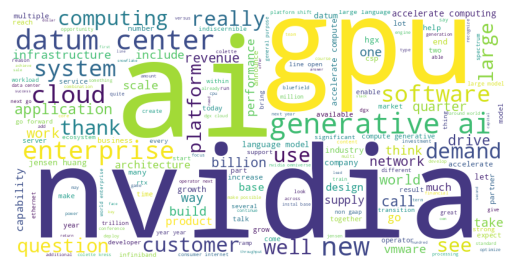

In [23]:
# Visualize only 1 document
text_idx = -1    # The most recent one
wordcloud = WordCloud(width = 800, height = 400, background_color = 'white').generate(corpus[text_idx])
plt.imshow(wordcloud)
plt.axis('off')
plt.show()

# Weight = TF-IDF weight

Drawing the word cloud with tf-idf weight is a bit harder. We use the method `generate_from_frequencies` and it takes a dictionary as the input.

The dictionary is in the following form:
```
word_weights = {
    'word_1': weight_1,
    'word_2': weight_2,
    ...
    'word_V': weight_V,
}
```

Firstly, re-run the `TfidfVectorizer`

In [24]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()
X_tfidf = vectorizer.fit_transform(corpus)

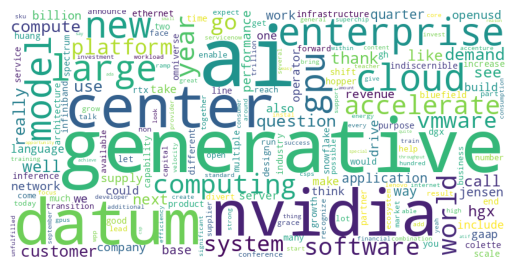

In [25]:
# Visualize only 1 document
vocab = vectorizer.get_feature_names_out()
weights = X_tfidf[text_idx,:].toarray().flatten()

word_weights = dict([(x, y) for x, y in zip(vocab, weights)])

wordcloud = WordCloud(width = 800, height = 400, background_color = 'white').generate_from_frequencies(word_weights)
plt.imshow(wordcloud)
plt.axis('off')
plt.show()